# Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is a statistical technique used to reduce the dimensionality of data while retaining most of the variation present in the dataset. PCA achieves this by finding new variables, called **principal components**, which are linear combinations of the original variables and are ordered in such a way that the first few retain most of the variation in the dataset.

## The Basic Idea of PCA

Given a dataset$\mathbf{X} \in \mathbb{R}^{n \times d}$ with $n$ data points and $d$ features, PCA finds a set of orthogonal axes, known as principal components, that capture the most variance in the data. These components are uncorrelated and are ordered by the amount of variance they capture.

## Dimensional Reduction with PCA
For one sample data $X^{(1)}=[x1, x2,...,x_m]$ m-features, the **first principal component (PC)** is the normalized linear combination of the features
$$Z_1=\phi_{11}x_1+\phi_{21}x_2+...+\phi_{m1}x_m$$
By normalized, we mean that $\sum_{j=1}^m\phi_{j1}^2=1$. The first PC vector is $\phi_1 = [\phi_{11}, \phi_{21},...,\phi_{m1}]^T$, also call the PC coefficients. 

Now you are given a $m\times n$ dataset $\mathbf{X}=[x_{ij}]$ with mean 0. We look for the 1st principal component has the linear combination of the sample feature values
$$z_{i1} = \phi_{11}x_{i1}+\phi_{21}x_{i2}+...+\phi_{m1}x_{im}$$
that has largest sample variance, subject to the constraint that $\sum_{j=1}^m\phi_{j1}^2=1$. The first principal component vector (coefficients) solves the optimizaion problem
$$\text{maximize} {\frac{1}{n}\sum_{i=1}^n(\sum_{j=1}^m\phi_{j1}x_{ij})^2}$$
subject to $\sum_{j=1}^m\phi_{j1}^2=1$. 
- The values $z_{11},z_{21},...,z_{n1}$ are the transform (or projection) of data $x_{ij}$ to the first principal component direction. It is also named as scores of the first principal component.
- The first PC loading vector (coefficients) $\phi_1 = [\phi_{11}, \phi_{21},...,\phi_{m1}]$ defines a direction in feature space along which the data vary the most.
- If we project the n data points onto this direction (1st PC), the projected values are the PC scores $z_{11},z_{21},...,z_{n1}$.

After the first PC ($Z_1$) of the features has been determined, we can find the second PC $Z_2$. Similarly, we have
$$z_{i2} = \phi_{12}x_{i1}+\phi_{22}x_{i2}+...+\phi_{m2}x_{im}$$
that has maximal variation out of all linear combination that are **uncorrelated with $Z_1$** 
- $\phi_2=[\phi_{12}, \phi_{22},...,\phi_{m2}]$ is the second PC coefficient (loading vector).
- Constraining $Z_2$ to be uncorrelated with $Z_1$ is equivalent to constraining the direction $\phi_2$, i.e. coefficients vector, or loading vector to be orthogonal to $\phi_1$.

## low-dimension projection from PCA
### Reduce from original feature dimension $m$ to $r$ ($r<<m$, e.g., r=10, m=100000)
In general we have a data matrix $\mathbf{X}$ contains $m$ features and $n$ samples. **Let $V_{m\times r}$ be the first $r$ principal component vector (coefficients), $Z_{r\times n}$ be the projected (transformed) data onto the $r$ PCs.**
$$
\begin{bmatrix}
z_{11} &z_{12} & ... &z_{1n} \\
z_{21} &z_{22} & ... &z_{2n} \\
\vdots \\
z_{r1} &z_{r2} & ... &z_{rn}
\end{bmatrix}_{r\times n} = \begin{bmatrix}
\phi_{11} & \phi_{12} & ... & \phi_{1m}\\
\phi_{21} & \phi_{22} & ... & \phi_{2m}\\
\vdots \\
\phi_{r1} & \phi_{r2} & ... & \phi_{rm}\\
\end{bmatrix}_{r\times m}\cdot\begin{bmatrix}
x_{11} & x_{12} & ... & x_{1n} \\
x_{21} & x_{22} & ... & x_{2n} \\
\vdots \\
x_{m1} & x_{m2} & ... & x_{mn} 
\end{bmatrix}_{m\times n}
$$
$$Z = V^T_r\cdot \mathbf{X}$$
- the $V_r$, $m\times r$ (each column represents the PC vector), is the truncated $r$ PC vector (coefficients) that can be computed via SVD of data matrix $\mathbf{X}$ or eigendecomposition of covariance matrix $\mathbf{X}^T\mathbf{X}$
- The reconstruction from r-dimension approximation is $\tilde{\mathbf{X}} = V_r Z$
  
Equivalently, if our data matrix $\mathbf{X}$ has shape $n\times m$ ($n$ samples, $m$ features)
$$
(\begin{bmatrix}
z_{11} &z_{12} & ... &z_{1n} \\
z_{21} &z_{22} & ... &z_{2n} \\
\vdots \\
z_{r1} &z_{r2} & ... &z_{rn}
\end{bmatrix}^T)_{n\times r} = \begin{bmatrix}
x_{11} & x_{12} & ... & x_{1m} \\
x_{21} & x_{22} & ... & x_{2m} \\
\vdots \\
x_{n1} & x_{n2} & ... & x_{nm} 
\end{bmatrix}_{n\times m}\cdot\begin{bmatrix}
\phi_{11} & \phi_{12} & ... & \phi_{1r}\\
\phi_{21} & \phi_{22} & ... & \phi_{2r}\\
\vdots \\
\phi_{m1} & \phi_{m2} & ... & \phi_{mr}\\
\end{bmatrix}_{m\times r}
$$
- $Z^T = \mathbf{X}V_r$
- Recover from PCA approximation is $\tilde{\mathbf{X}} = Z^TV_r^T$


### Key Steps in PCA:

1. **Centering the Data**: Subtract the mean of each feature from the data to center it around zero.
   
   $$ \mathbf{X}_{centered} = \mathbf{X} - \mu $$
   
   where $\mu$ is the mean vector of the dataset.

2. **Covariance Matrix**: Compute the covariance matrix of the centered data.
   
   $$ \mathbf{C} = \frac{1}{n-1} \mathbf{X}_{centered}^\top \mathbf{X}_{centered} $$

3. **Eigenvalue Decomposition**: Perform eigendecomposition on the covariance matrix $\mathbf{C}$ to obtain the eigenvalues $\lambda$ and eigenvectors $\mathbf{v}$.

   $$ \mathbf{C} \mathbf{v}_i = \lambda_i \mathbf{v}_i $$

4. **Ordering Eigenvalues and Eigenvectors**: Order the eigenvalues $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_d $and their corresponding eigenvectors.

5. **Principal Components**: Select the top $k$ eigenvectors, which correspond to the largest $k$ eigenvalues. These eigenvectors form the principal components.
   
   $$ \mathbf{Z} = \mathbf{X}_{centered} \mathbf{V}_k $$

   where $\mathbf{V}_k$ is a matrix of the top $k$ eigenvectors, and $\mathbf{Z}$ represents the data in the reduced $k$-dimensional space.

## Properties of PCA

- **Variance Maximization**: Each principal component is a direction in the data space along which the variance of the projected data is maximized.
  
- **Orthogonality**: The principal components are orthogonal to each other, meaning they capture linearly independent directions in the data.

- **Dimensionality Reduction**: By selecting the top $k$ principal components, PCA reduces the dimensionality of the data while retaining most of the variance.

## Mathematical Formulation of PCA

Let $\mathbf{X} \in \mathbb{R}^{n \times d}$ represent a data matrix with $n$ observations and $d$ dimensions. PCA seeks to project the data onto a lower-dimensional subspace by solving the following optimization problem:

- **Objective**: Maximize the variance of the projected data on the new axes (principal components).

For each principal component $\mathbf{v}_i$, this is formulated as:
$$ \text{maximize} \quad \mathbf{v}_i^\top \mathbf{C} \mathbf{v}_i $$
subject to $\mathbf{v}_i^\top \mathbf{v}_i = 1$, ensuring that each principal component has unit length.

## Covariance Matrix and Eigenvalue Decomposition

The covariance matrix $\mathbf{C}$ provides a summary of the relationships between the different dimensions of the data. The eigenvectors of this matrix correspond to the directions of maximum variance, and the eigenvalues give the magnitude of the variance along these directions.

- The **eigenvalue** $\lambda_i$ represents the variance explained by the $i$-th principal component.
  
- The **eigenvector** $\mathbf{v}_i$ provides the direction of the $i$-th principal component.

## Example: PCA with Eigenvalue Decomposition

Given a dataset $\mathbf{X}$, the following steps show how to compute the principal components using eigenvalue decomposition:

1. Compute the covariance matrix of the dataset $\mathbf{C}$.
2. Perform eigenvalue decomposition to get the eigenvalues and eigenvectors.
3. Order the eigenvectors by their corresponding eigenvalues.
4. Project the original data onto the top $k$ eigenvectors to reduce its dimensionality.


In [194]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a synthetic 2D dataset
np.random.seed(42)
mean = [1, 1]
cov = [[4, 2], [2, 3]]  # covariance matrix
X = np.random.multivariate_normal(mean, cov, 100)

X = X.reshape((2, -1))
print(X.shape)
Xmean= np.mean(X, axis=1, keepdims=True)
print(Xmean.shape)

(2, 100)
(2, 1)


(2, 100)
The centered data shape is:  (2, 100)


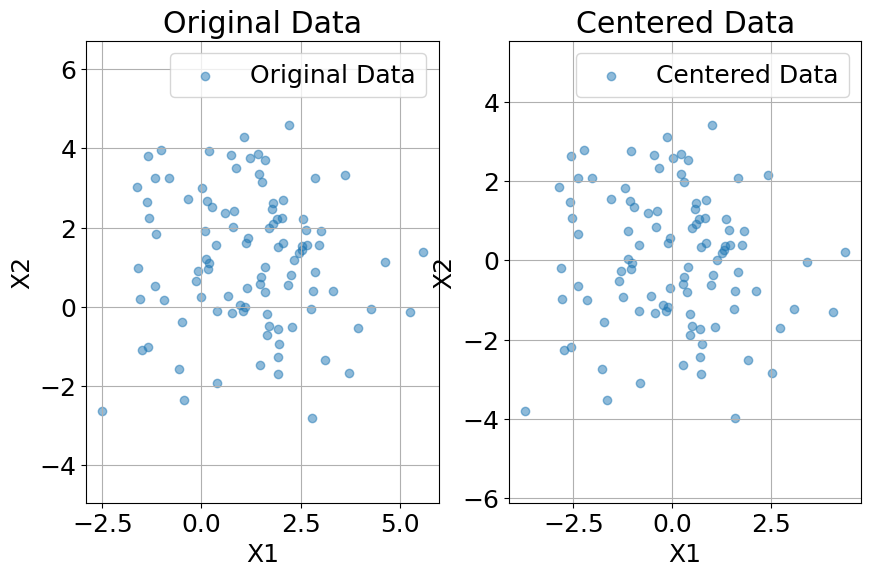

In [195]:
# 3. Center the data (subtract the mean)
X_centered = X - Xmean
print(X_centered.shape)

#plot the centered data and the the original data
fig = plt.figure(figsize=(10, 6))
#This subplot shows the original data
ax1 = fig.add_subplot(121)
ax1.scatter(X[0, :], X[1, :], alpha=0.5, label='Original Data')
ax1.set_title('Original Data')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.axis('equal')
ax1.legend()
ax1.grid(True)
#this subplot shows the centered data
ax2 = fig.add_subplot(122)
ax2.scatter(X_centered[0, :], X_centered[1, :], alpha=0.5, label='Centered Data')
ax2.set_title('Centered Data')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.axis('equal')
ax2.legend()
ax2.grid(True)
print("The centered data shape is: ", X_centered.shape)

In [196]:
A_centered = X_centered
# Step 3: Compute the covariance matrix C = A_centered.T @ A_centered
C = np.cov(A_centered)

# Step 4: Compute the eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(C)

print("Covariance matrix shape is: ", C.shape)
print("eigenvector shape is: ", eigenvectors.shape)
print(eigenvalues)

# Step 5: Sort the eigenvalues and corresponding eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Step 6: Print the eigenvalues and eigenvectors
print("Eigenvalues (Variance explained by each PC):\n", eigenvalues)
print("1st (Principal Components):\n", eigenvectors[:,0])
print("2nd (Principal Components):\n", eigenvectors[:,1])

Covariance matrix shape is:  (2, 2)
eigenvector shape is:  (2, 2)
[2.51311217 2.99923371]
Eigenvalues (Variance explained by each PC):
 [2.99923371 2.51311217]
1st (Principal Components):
 [ 0.45505531 -0.89046318]
2nd (Principal Components):
 [-0.89046318 -0.45505531]


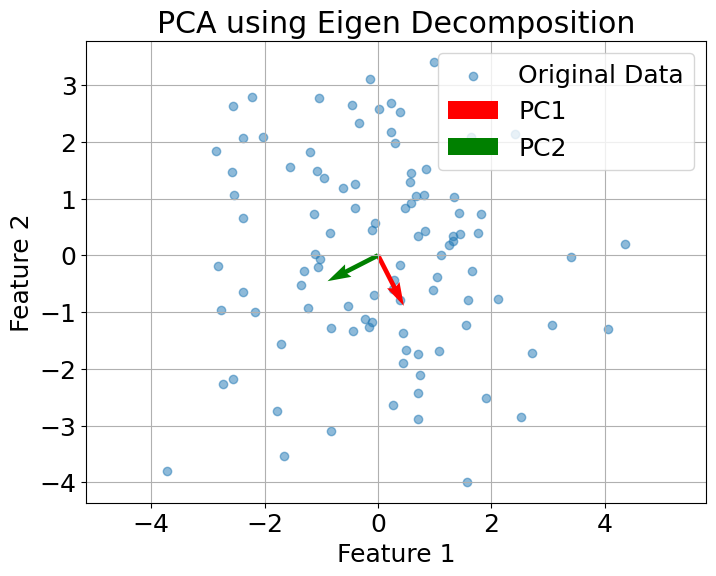

In [197]:
# Step 7: Project the data onto the principal components (PCA transformation)
# For example, projecting data onto the first principal component
A_pca = eigenvectors.T @ A_centered

# Step 8: Plot the results (optional, to visualize the PCA components)
plt.figure(figsize=(8, 6))

# Plot original centered data
plt.scatter(A_centered[0, :], A_centered[1, :], label='Original Data', alpha=0.5)

# Plot the principal components
plt.quiver(0, 0, eigenvectors[0, 0], eigenvectors[1, 0], angles='xy', scale_units='xy', scale=1, color='r', label='PC1')
plt.quiver(0, 0, eigenvectors[0, 1], eigenvectors[1, 1], angles='xy', scale_units='xy', scale=1, color='g', label='PC2')

plt.title('PCA using Eigen Decomposition')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.legend()
plt.axis('equal')
plt.show()

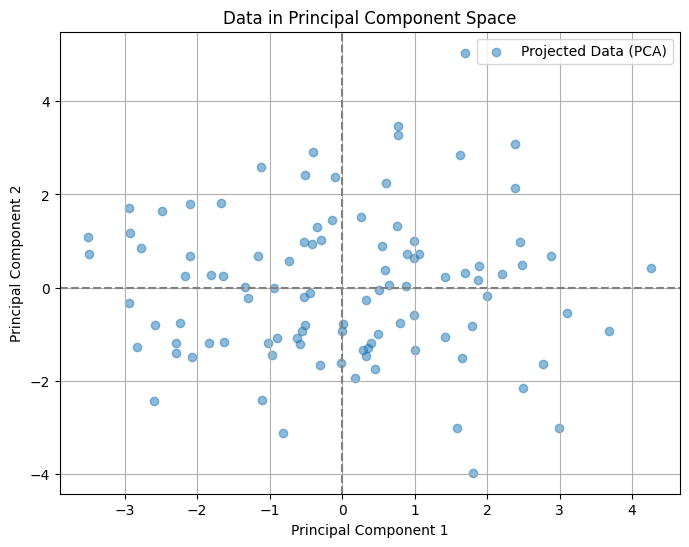

In [170]:
# 9. Plot the projected data in the PCA space
plt.figure(figsize=(8, 6))
plt.scatter(A_pca[0, :], A_pca[1, :], alpha=0.5, label='Projected Data (PCA)')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Data in Principal Component Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

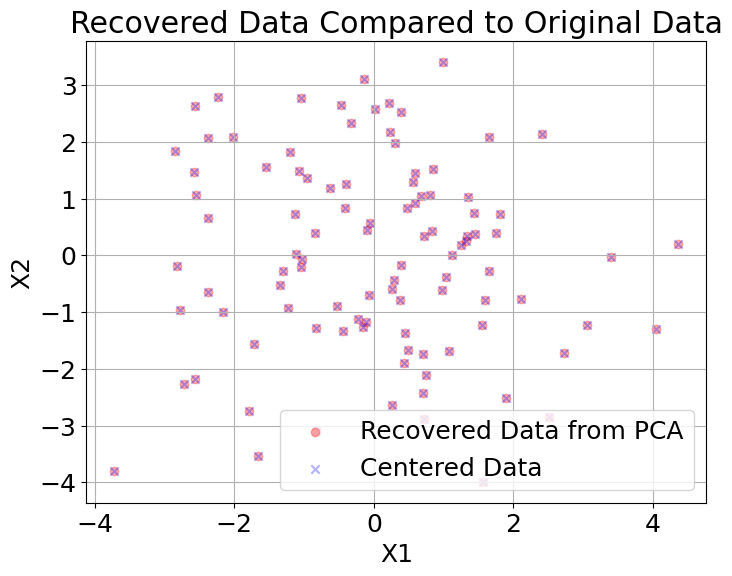

In [198]:
# Step 9: Recover the original centered data using all principal components
A_recovered = eigenvectors @ A_pca

plt.figure(figsize=(8, 6))
plt.scatter(A_recovered[0, :], A_recovered[1, :], alpha=0.3, label='Recovered Data from PCA', color ='r')
plt.scatter(A_centered[0, :], A_centered[1, :], alpha=0.3, label='Centered Data', marker='x', color ='b')
plt.title('Recovered Data Compared to Original Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()

### Another 3D data example, reduce 3D to 2D

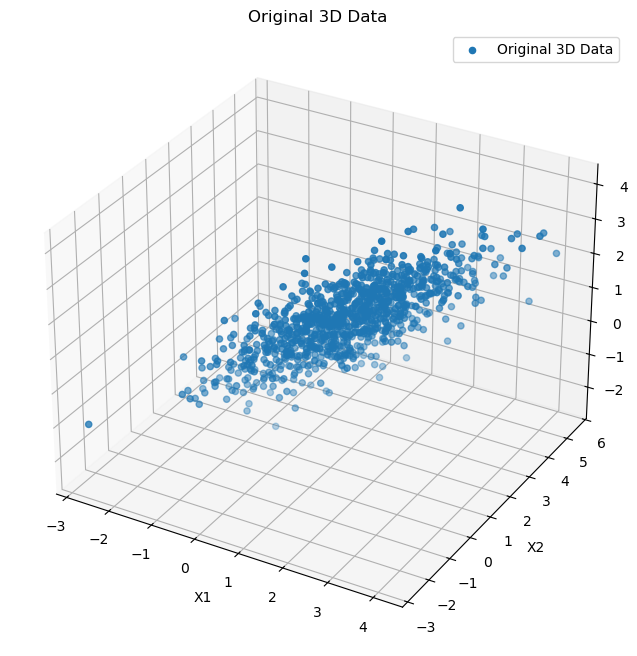

In [17]:
# 1. Generate synthetic 3D dataset
#np.random.seed(42)
#mean = [0, 0, 0]
#cov = [[4, 2, 0], [2, 3, 0], [0, 0, 1]]  # covariance matrix for 3D
#X_3D = np.random.multivariate_normal(mean, cov, 1000)

# Step 1: Create random 3D dataset
np.random.seed(42)
mean = [1, 2, 1]
cov = [[1, 0.9, 0.7], [0.9, 1, 0.5], [0.7, 0.5, 1]]  # Covariance matrix
data_3d = np.random.multivariate_normal(mean, cov, 1000)  # 100 samples of 3D data

# 2. Plot the original 3D data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], 'b', label='Original 3D Data')
ax.set_title('Original 3D Data')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
plt.legend()
plt.show()

In [18]:
# Step 2: Center the data (subtract the mean)
mean_data = np.mean(data_3d, axis=0)
data_centered = data_3d - mean_data

# Step 3: Compute the covariance matrix of the centered data
cov_matrix = np.cov(data_centered.T)  # Covariance matrix of the centered data
print("shape of cov_matrix is", cov_matrix.shape)

shape of cov_matrix is (3, 3)


In [19]:
# Step 4: Perform eigendecomposition on the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("eigenvalues before sorting: ", eigenvalues)

# Step 5: Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Print the eigenvalues and eigenvectors (principal components)
print("Eigenvalues:", eigenvalues)
print("1st Eigenvectors (Principal Components):\n", eigenvectors[:, 0])
print("2nd Eigenvectors (Principal Components):\n", eigenvectors[:, 1])

eigenvalues before sorting:  [2.27273412 0.06080917 0.53150766]
Eigenvalues: [2.27273412 0.53150766 0.06080917]
1st Eigenvectors (Principal Components):
 [0.63460946 0.59639713 0.4915092 ]
2nd Eigenvectors (Principal Components):
 [-0.15491708 -0.52490726  0.83694269]


In [20]:
# print the eigenvector shape
print("eigenvector shape: ", eigenvectors.shape)

# Step 6: Project the data onto the first two principal components
projected_data_2d = data_centered @ eigenvectors[:, :2]

eigenvector shape:  (3, 3)


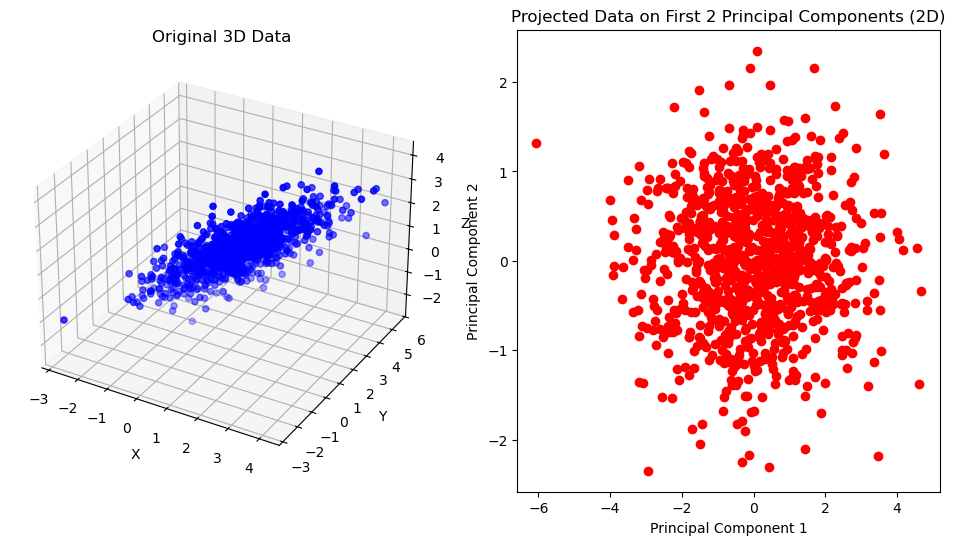

In [21]:
# Plot the 3D original data
fig = plt.figure(figsize=(12, 6))

# Original 3D data
ax = fig.add_subplot(121, projection='3d')
ax.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], c='b', label='Original Data')
ax.set_title('Original 3D Data')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Plot the 2D projected data (reduced to 2D)
ax2 = fig.add_subplot(122)
ax2.scatter(projected_data_2d[:, 0], projected_data_2d[:, 1], c='r', label='Projected Data (2D)')
ax2.set_title('Projected Data on First 2 Principal Components (2D)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
plt.show()


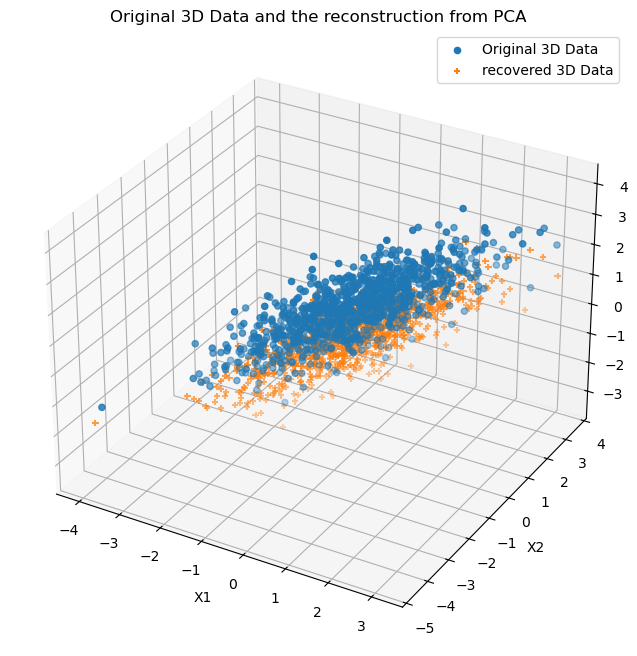

In [22]:
# 10. (Optional) Recover data by inverting PCA transformation
data3d_recover = projected_data_2d @ eigenvectors[:, :2].T
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_centered[:, 0], data_centered[:, 1], data_3d[:, 2], 'b', label='Original 3D Data')
ax.scatter(data3d_recover[:, 0], data3d_recover[:, 1], data3d_recover[:, 2], marker='+', label='recovered 3D Data')
ax.set_title('Original 3D Data and the reconstruction from PCA')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
plt.legend()
plt.show()

### image compression

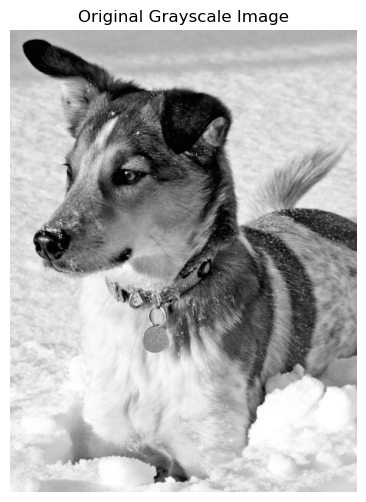

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Step 1: Load the image and convert to grayscale
image = imread('./figures/dog.jpg')
image_gray = np.mean(image, axis=2)  # Simple grayscale conversion by averaging RGB

# Show original image
plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

In [2]:
# Step 2: Flatten the 2D image into 2D array for PCA
h, w = image_gray.shape
A = image_gray / 255.0  # Normalize the pixel values to [0, 1]

# Step 3: Compute the covariance matrix
mean_A = np.mean(A, axis=0)
A_centered = A - mean_A
print("A_centered shape is: ", A_centered.shape)

A_centered shape is:  (2000, 1500)


In [3]:
cov_matrix = np.dot(A_centered.T, A_centered) / (h - 1)

# Step 4: Perform eigen decomposition of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("first 10 eigenvalues: ", eigenvalues[:10])

first 10 eigenvalues:  [31.23008837 26.27109952 14.57038521  4.25778228  2.35829093  2.33443299
  1.82936429  1.65075413  1.0897695   0.94346432]


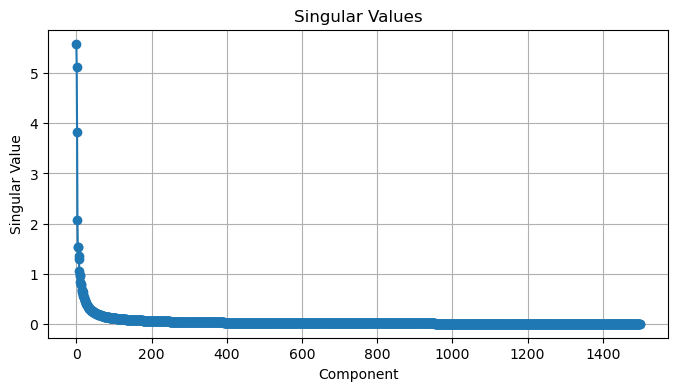

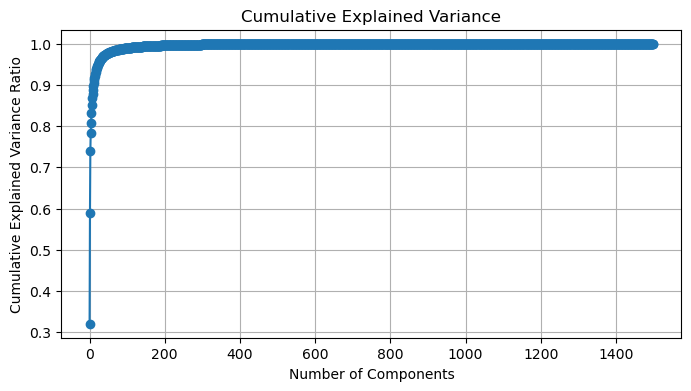

In [4]:
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Step 5: Plot the singular values (square root of eigenvalues)
singular_values = np.sqrt(eigenvalues)
plt.figure(figsize=(8, 4))
plt.plot(singular_values, marker='o')
plt.title("Singular Values")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

# Step 6: Plot the cumulative explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance_ratio, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True)
plt.show()

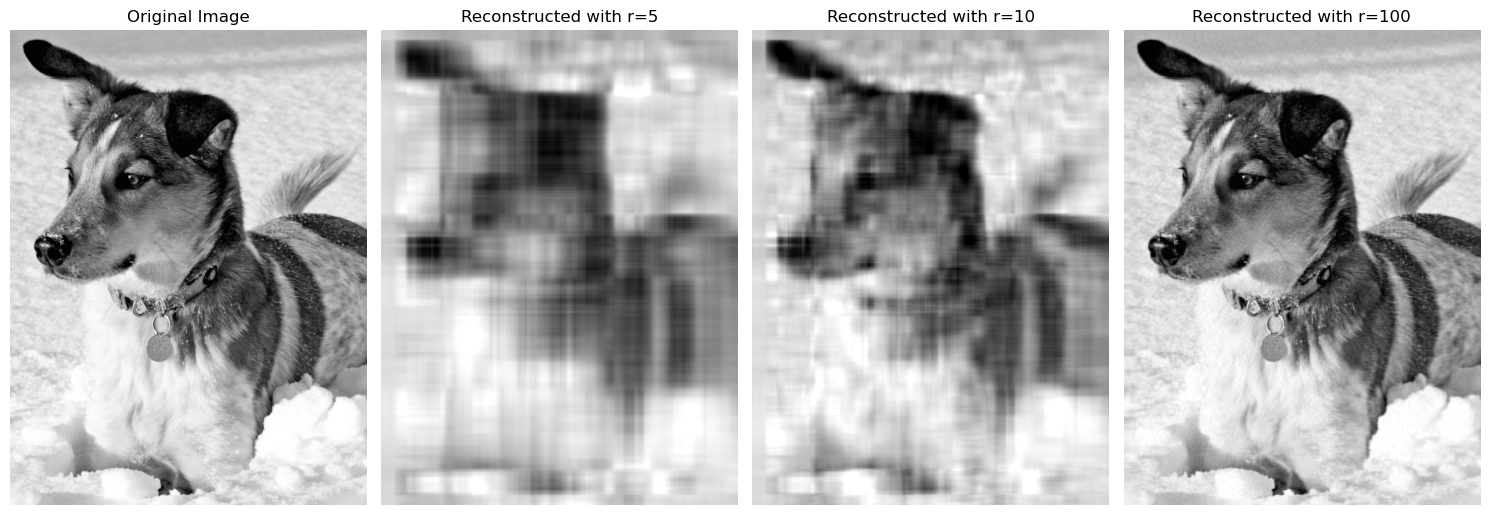

In [5]:
# Step 7: Reconstruct the image using different numbers of principal components
def reconstruct_image(A_centered, eigenvectors, mean_A, r):
    U_r = eigenvectors[:, :r]
    A_compressed = np.dot(A_centered, U_r).dot(U_r.T) + mean_A
    return np.clip(A_compressed, 0, 1)

# Plot original and reconstructed images for different r values
r_values = [5, 10, 100]
fig, ax = plt.subplots(1, len(r_values) + 1, figsize=(15, 6))

# Original image
ax[0].imshow(A, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

# Reconstructed images
for i, r in enumerate(r_values):
    A_reconstructed = reconstruct_image(A_centered, eigenvectors, mean_A, r)
    ax[i + 1].imshow(A_reconstructed, cmap='gray')
    ax[i + 1].set_title(f"Reconstructed with r={r}")
    ax[i + 1].axis('off')

plt.tight_layout()
plt.show()

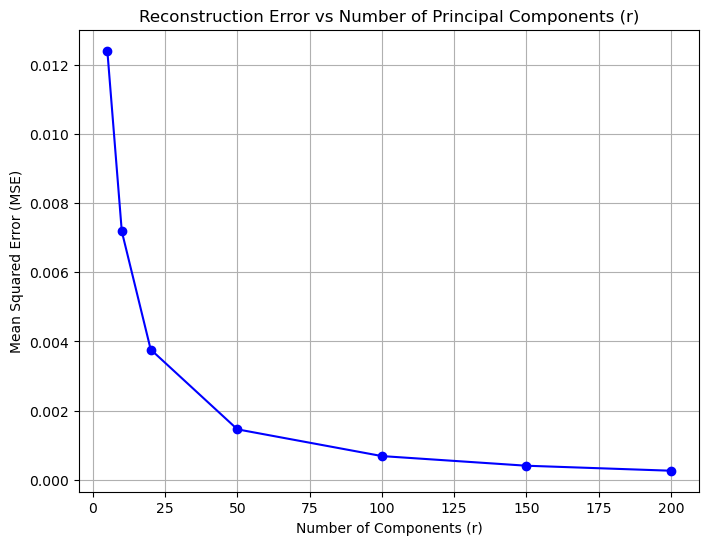

In [6]:
def mean_squared_error(A, B):
    return np.mean((A - B) ** 2)

r_values = [5, 10, 20, 50, 100, 150, 200]  # Test different values of r
reconstruction_errors = []

for r in r_values:
    A_reconstructed = reconstruct_image(A_centered, eigenvectors, mean_A, r)
    error = mean_squared_error(A, A_reconstructed)
    reconstruction_errors.append(error)

# Step 7: Plot the reconstruction error vs r
plt.figure(figsize=(8, 6))
plt.plot(r_values, reconstruction_errors, marker='o', linestyle='-', color='b')
plt.title("Reconstruction Error vs Number of Principal Components (r)")
plt.xlabel("Number of Components (r)")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

## image denoising

(1280, 1920)


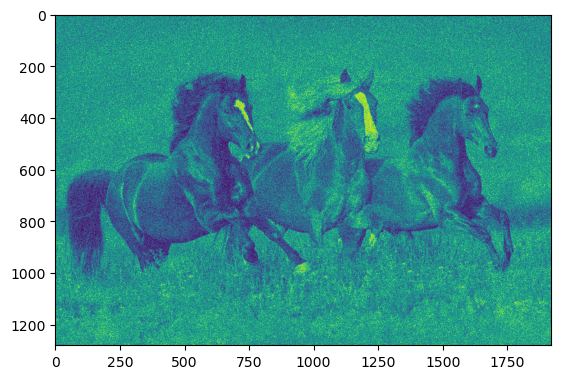

In [12]:
#image = imread('./figures/panda.png')
image = imread('./figures/horse.jpg')
image_gray = np.mean(image, axis=2)

image_array = np.array(image_gray) / 255.0  # Normalize the pixel values to [0, 1]
noise = np.random.normal(0, 1, image_array.shape)
noisy_image = np.clip(image_array + 0.3*noise, 0, 1)  # Add noise and clip between 0 and 1

fig = plt.figure()
plt.imshow(noisy_image)
print(noisy_image.shape)

(1920,)


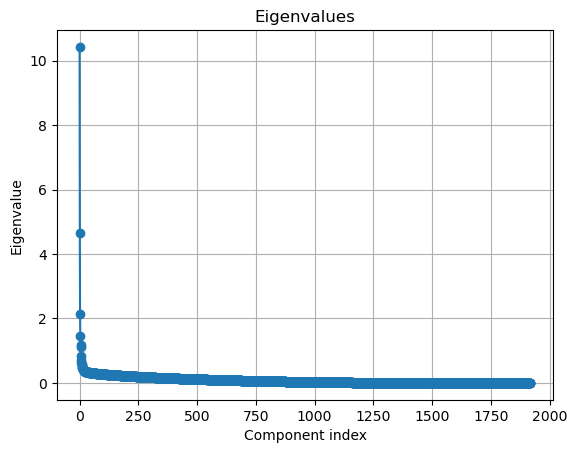

In [13]:
h, w = noisy_image.shape
flat_image = noisy_image.reshape(h, w)

# Center the data by subtracting the mean
mean_vector = np.mean(flat_image, axis=0)
centered_image = flat_image - mean_vector

# Compute the covariance matrix
covariance_matrix = np.cov(centered_image, rowvar=False)

# Perform eigendecomposition of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Sort eigenvalues and corresponding eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print(eigenvalues.shape)
# Plot the eigenvalues
plt.plot(eigenvalues, marker='o')
plt.title('Eigenvalues')
plt.xlabel('Component index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

(-0.5, 1919.5, 1279.5, -0.5)

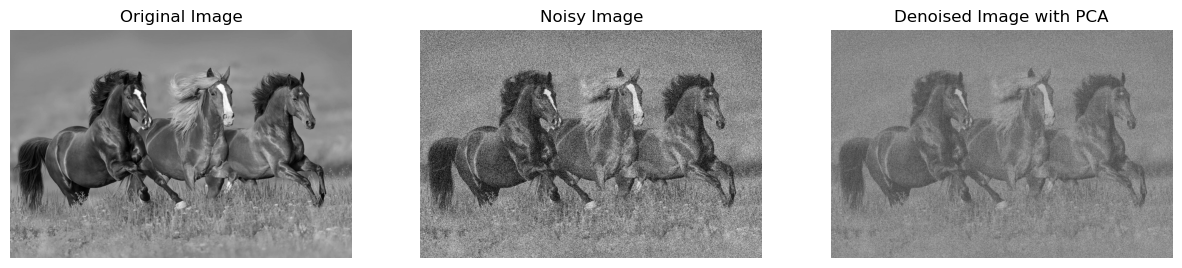

In [15]:
n_components = 500
# Choose the top 'n_components' eigenvectors
principal_components = eigenvectors[:, :n_components]

# Project the centered image onto the principal components
transformed_image = np.dot(centered_image, principal_components)

# Reconstruct the image using the top principal components
reconstructed_image = np.dot(transformed_image, principal_components.T) + mean_vector
reconstructed_image = reconstructed_image.reshape(h, w)


fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(image_array, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
# Noisy Image
axs[1].imshow(noisy_image, cmap='gray')
axs[1].set_title('Noisy Image')
axs[1].axis('off')
# Denoised Image
axs[2].imshow(reconstructed_image, cmap='gray')
axs[2].set_title('Denoised Image with PCA')
axs[2].axis('off')

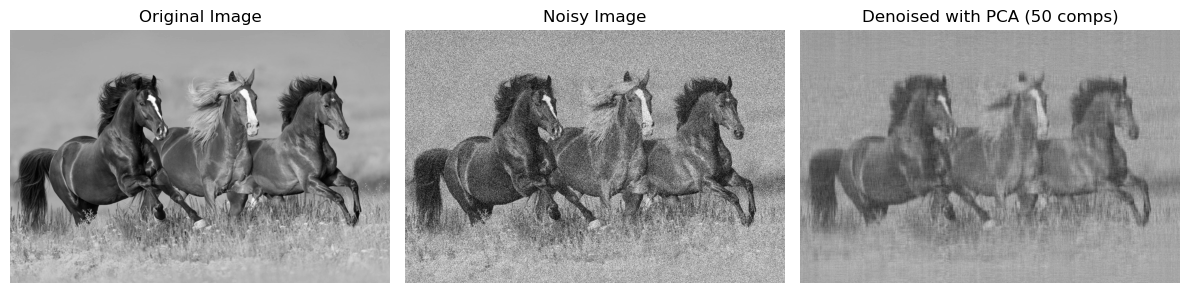

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage import io, color, img_as_float

# 1. Load image and convert to grayscale
img = io.imread("./figures/horse.jpg")
if img.ndim == 3:  # if RGB, convert to grayscale
    img_gray = color.rgb2gray(img)
else:
    img_gray = img
img_gray = img_as_float(img_gray)  # ensure values are float in [0,1]

# 2. Add Gaussian noise
rng = np.random.default_rng(42)
noisy_img = img_gray + 0.3 * rng.standard_normal(img_gray.shape)
noisy_img = np.clip(noisy_img, 0, 1)

# 3. Apply PCA for denoising
# Treat each row of the image as a data sample
pca = PCA(n_components=50)   # keep 50 components
X = pca.fit_transform(noisy_img)
X_reconstructed = pca.inverse_transform(X)

# 4. Plot results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title("Noisy Image")
axes[1].axis("off")

axes[2].imshow(X_reconstructed, cmap='gray')
axes[2].set_title("Denoised with PCA (50 comps)")
axes[2].axis("off")

plt.tight_layout()
plt.show()